In [6]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from build_dataset import build_dataset
from itertools import product
%load_ext autoreload
%autoreload 2
%matplotlib inline

#### Taking the words of the corpus

In [7]:
words_corpus = open("names.txt", "r").read().splitlines()
words_corpus[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [8]:
print(f"The total len of the words of the corpus are {len(words_corpus)}")

The total len of the words of the corpus are 32033


#### Build the vocabulary of characters and mapping to/from integers

In [9]:
chars_corpus = sorted(list(set(''.join(words_corpus)))) #Set so it doesnt repeat the words
print(f"This are the words in the corpus{chars_corpus} and the len {len(chars_corpus)}")

This are the words in the corpus['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'] and the len 26


In [10]:
stoi = {letter:index+1 for index, letter in enumerate(chars_corpus)} #This for making the letters and the index
stoi['.'] = 0 #Its the first index its going to be .
print(stoi)

{'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26, '.': 0}


In [11]:
itos = {index:letter for letter,index in stoi.items()}
print(len(itos))

27


#### Build the Dataset

In [12]:
import random
block_size_context = 3  #the context length: how many characters 
                        # the model sees to predict the next one
                        # e.g. "_ _ _ -> ?"


random.seed(42) #This is for reproducibility
random.shuffle(words_corpus)
n1 = int(0.80 * len(words_corpus)) #This is for the training set
n2 = int(0.90 * len(words_corpus)) #This is for the validation set and the test set

X_training, Y_training = build_dataset(words_corpus=words_corpus[:n1],block_size=block_size_context, stoi=stoi) #until 80%
X_validation, Y_validation = build_dataset(words_corpus=words_corpus[n1:n2], block_size=block_size_context, stoi=stoi) #10 for validation
X_test, Y_test = build_dataset(words_corpus=words_corpus[n2:], block_size=block_size_context, stoi=stoi)#10 for test

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [13]:
import torch.nn.init as init

#MLP revisited hyper parameters
embedding_dim = 10 #The dimensionality of the character embedding
hidden_size_first_layer = block_size_context * embedding_dim #This is because we have the number of neurons is the embedding dim * number of layers
hidden_size_second_layer = 200 # the number of neurons in the hidden layer of the MLP
batch_size = 32
lenght_characters_dataset = len(itos)
generator = torch.Generator().manual_seed(2147483647)


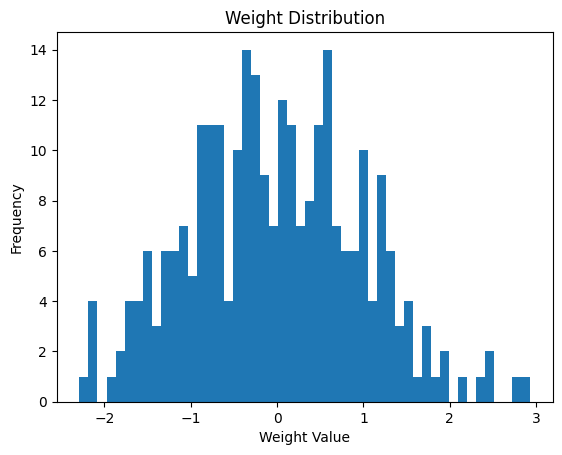

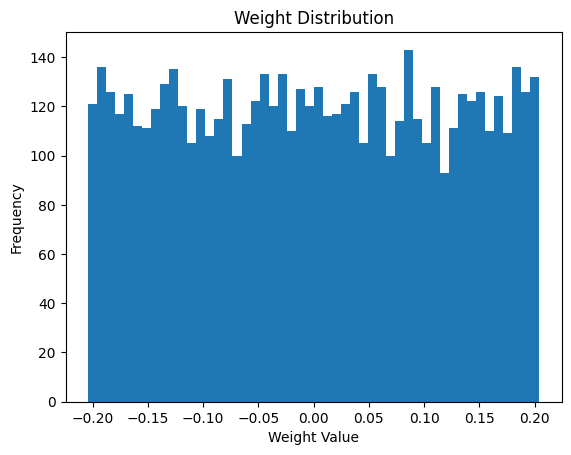

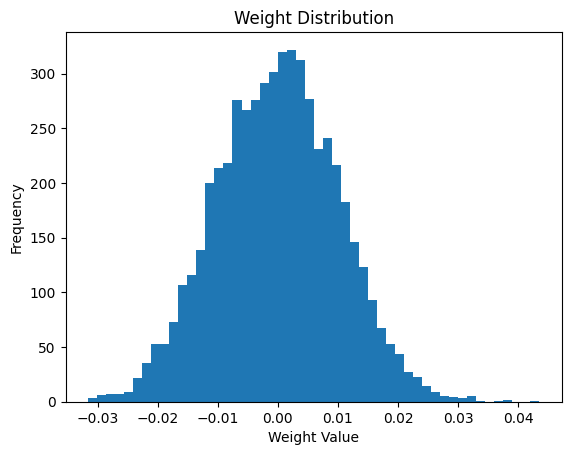

In [14]:

C = torch.randn((lenght_characters_dataset, embedding_dim), generator=generator) #The look out matrix, is the matrix with the embeddings
W1 = torch.randn((hidden_size_first_layer, hidden_size_second_layer), generator=generator) # 30 neurons first layers, 200 neurons second layer
#b1 = torch.zeros((hidden_size_second_layer)) # The bias is always the next layer
W2 = torch.randn((hidden_size_second_layer, lenght_characters_dataset)) #The 200 neurons of second layer, the number of outputs
b2 = torch.randn(lenght_characters_dataset, generator=generator) * 0

W2 = W2 * 0.01
init.kaiming_uniform_(W1, a=5/3, nonlinearity="tanh")


#BatchNorm parameters
bngain = torch.ones((1, hidden_size_second_layer))
bnbias = torch.zeros((1, hidden_size_second_layer))
bnmean_running = torch.zeros((1, hidden_size_second_layer))
bnstd_running = torch.ones((1, hidden_size_second_layer))



parameters = [C, W1, W2, b2, bngain, bnbias]


C_weights = C.detach().numpy()
plt.hist(C_weights.flatten(), bins=50)
plt.title("Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.show()


W1_weights = W1.detach().numpy()
plt.hist(W1_weights.flatten(), bins=50)
plt.title("Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.show()


W2_weights = W2.detach().numpy()
plt.hist(W2_weights.flatten(), bins=50)
plt.title("Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.show()

In [15]:
print(f"The total number of parameters {sum(p.nelement() for p in parameters)}")

The total number of parameters 12097


In [16]:
for p in parameters:
    p.requires_grad = True #Functions so the gradients are active to being changed and when loss.backward() there is going to be and update

In [17]:
lre = torch.linspace(-3, 0 , 1000) #To create from range -3 to 0 samples
lrs = 10**lre #To normalize it so we have the learning lare brom 0.0010 to 1

In [18]:
lr_index = []
loss_index = []
step_index = []
EPOCHS = 200000
max_steps = 200000

In [19]:
idx = 98869
contexto = X_training[idx]
print(contexto)  
siguiente = Y_training[idx]
print(siguiente)
print([itos[i.item()] for i in contexto], '->', itos[siguiente.item()])

tensor([25, 18,  4])
tensor(9)
['y', 'r', 'd'] -> i


In [39]:
#First layer -> BatchNorm -> Second Layer(tahn)

loss_total = list()
for index in range(EPOCHS):
    #Creating the minibatch
    ix = torch.randint(0, X_training.shape[0], (batch_size,), generator=generator) #Cada iteración → 32 índices random de TODO el dataset → El mismo ejemplo puede aparecer en muchas iteraciones, o no aparecer nunca en miles de pasos
    Xb, Yb = X_training[ix], Y_training[ix]
    
    #Forward Pass
    embedding = C[Xb]
    embcat = embedding.view(embedding.shape[0], -1)
    
    
    #linear Layer
    hpreact = embcat @ W1 #+ b1 # hidden layer pre-activation
    
    
    #BatchNorm 
    # -------------------------------------------------------------
    bnmeani = hpreact.mean(0,keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
        
    # -------------------------------------------------------------
    #Non-Linearity
    hidden_layer_tahn = torch.tanh(hpreact)  #View -> (32, 3, 10) → (32, 30)
    logits = hidden_layer_tahn @ W2 + b2 #(32, 27) its the one to see how weel it does the prediction
    loss = F.cross_entropy(logits, Yb)
    
    #BackWard pass
    for p in parameters:
        p.grad = None #Transform the gradients to 0 so it can be update
    loss.backward()

    # update
    lr = 0.1 if index < 100000 else 0.01
    for p in parameters:
        if p.grad is not None:
            p.data += -lr * p.grad

    #track stats
    if index % 10000 == 0:
        print(f'{index:7d}/{max_steps:7d}: {loss.item():.4f}')
    #lr_index.append(lre[index])
    #step_index.append(index)
    loss_index.append(loss.log10().item())
    #loss_total.append(loss.item())

print(loss.item())

      0/ 200000: 2.0704
  10000/ 200000: 2.2257
  20000/ 200000: 2.2647
  30000/ 200000: 2.2771
  40000/ 200000: 2.0259
  50000/ 200000: 2.5403
  60000/ 200000: 2.0494
  70000/ 200000: 2.1405
  80000/ 200000: 1.9832
  90000/ 200000: 2.0163
 100000/ 200000: 2.7324
 110000/ 200000: 2.2665
 120000/ 200000: 1.8227
 130000/ 200000: 2.1839
 140000/ 200000: 1.8658
 150000/ 200000: 2.1601
 160000/ 200000: 2.0339
 170000/ 200000: 1.9170
 180000/ 200000: 2.2266
 190000/ 200000: 2.1298
1.8171652555465698


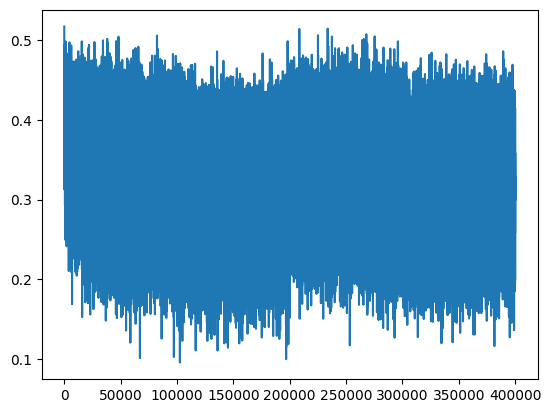

In [40]:
plt.plot(loss_index)

### With BatchNorm


In [41]:
# Calibrate the batch norm at the end of the training == Inference
with torch.no_grad():
    # pass the training set through
    emb = C[X_training]
    print(emb.shape)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1
    # Measure the mean/std over the entire training set
    bmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

torch.Size([182580, 3, 10])


In [42]:
@torch.no_grad() #This decorator disables gradient tracking
def split_loss(split : str) -> None:
    x, y = {
        'train' : (X_training, Y_training),
        'val' : (X_validation, Y_validation),
        'test' : (X_test, Y_test)
    }[split] # Its like a if statement of the code
    
    emb = C[x] #(N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    hpreact = embcat @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    hidden_layer_tahn = torch.tanh(hpreact)
    logits = hidden_layer_tahn @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.057955265045166
val 2.104189395904541


### Torch implementation for BatchNorm

In [57]:
from mlp_torch import Linear, BatchNorm1D, Tanh
import torch
%load_ext autoreload
%autoreload 2
%matplotlib inline


n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
#MLP revisited hyper parameters
embedding_dim = 10 #The dimensionality of the character embedding
hidden_size_first_layer = block_size_context * embedding_dim #This is because we have the number of neurons is the embedding dim * number of layers
hidden_size_second_layer = 200 # the number of neurons in the hidden layer of the MLP
batch_size = 32
lenght_characters_dataset = len(itos)
generator = torch.Generator().manual_seed(2147483647)

lenght_characters_dataset

27

In [59]:
layers = [
  Linear(n_embd * block_size_context, n_hidden, bias=False,generator=generator), BatchNorm1D(n_hidden), Tanh(), #First linear Layer ((n_embedding * block_size), hidden_layer)
  Linear(n_hidden, n_hidden, bias=False, generator=generator), BatchNorm1D(n_hidden), Tanh(), #Second Linear layer (fan_in,fan_out)
  Linear(n_hidden, n_hidden, bias=False, generator=generator), BatchNorm1D(n_hidden), Tanh(), #Third Linear layer (fan_in,fan_out)
  Linear(n_hidden, n_hidden, bias=False, generator=generator), BatchNorm1D(n_hidden), Tanh(), #Fourth Linear layer (fan_in,fan_out)
  Linear(n_hidden, n_hidden, bias=False, generator=generator), BatchNorm1D(n_hidden), Tanh(), #Fifth Linear layer (fan_in,fan_out)
  Linear(n_hidden, lenght_characters_dataset, bias=False, generator=generator), BatchNorm1D(lenght_characters_dataset), # Ultimate (fan_out, lenght_character_dataset = 27)
]

In [60]:
with torch.no_grad():
    #Last layer: make less confident
    layers[-1].gamma *= 0.1
    # all others layer: apply gain
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

In [61]:
parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [62]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, X_training.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_training[ix], Y_training[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization


      0/ 200000: 3.2958


layer 2 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 8 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 11 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 14 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'activation distribution')

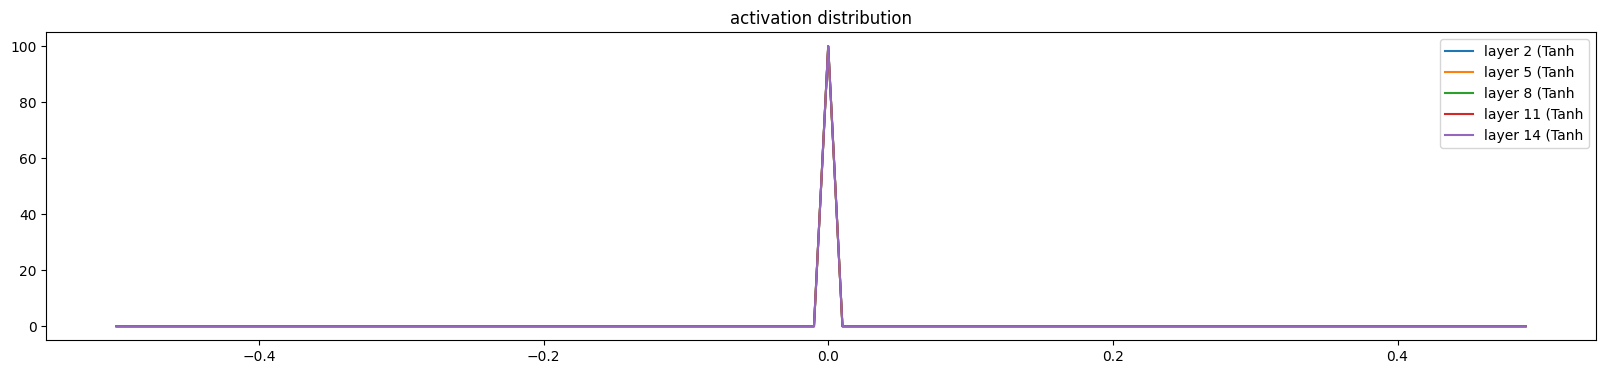

In [63]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends)
plt.title('activation distribution')

layer 2 (      Tanh): mean +0.000000, std 0.000000e+00
layer 5 (      Tanh): mean +0.000000, std 0.000000e+00
layer 8 (      Tanh): mean +0.000000, std 0.000000e+00
layer 11 (      Tanh): mean +0.000000, std 0.000000e+00
layer 14 (      Tanh): mean +0.000000, std 0.000000e+00


Text(0.5, 1.0, 'gradient distribution')

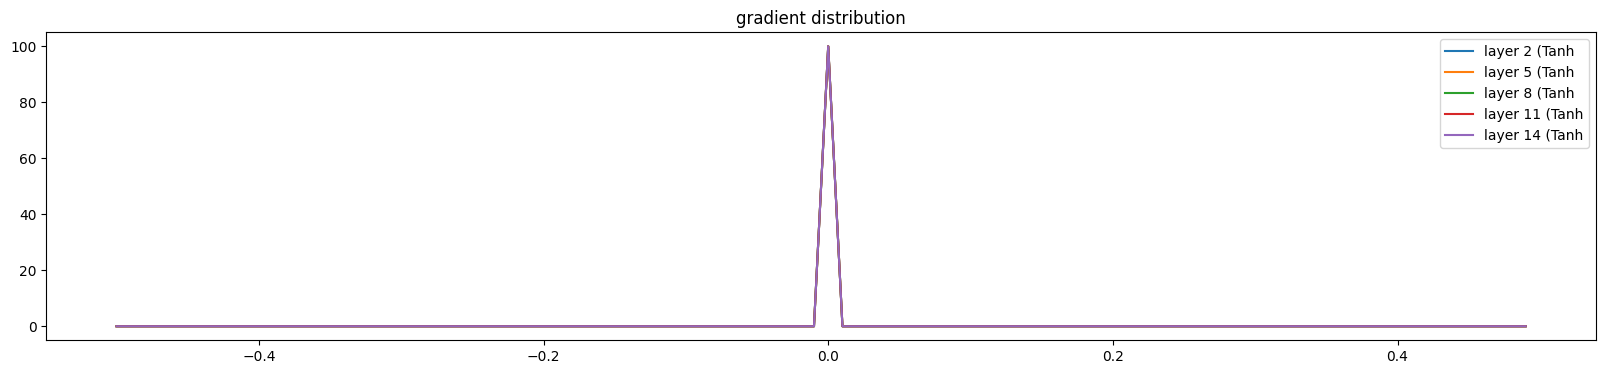

In [64]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean +0.000000 | std 0.000000e+00 | grad:data ratio 0.000000e+00
weight  (30, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight (100, 100) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan
weight  (100, 27) | mean +0.000000 | std 0.000000e+00 | grad:data ratio nan


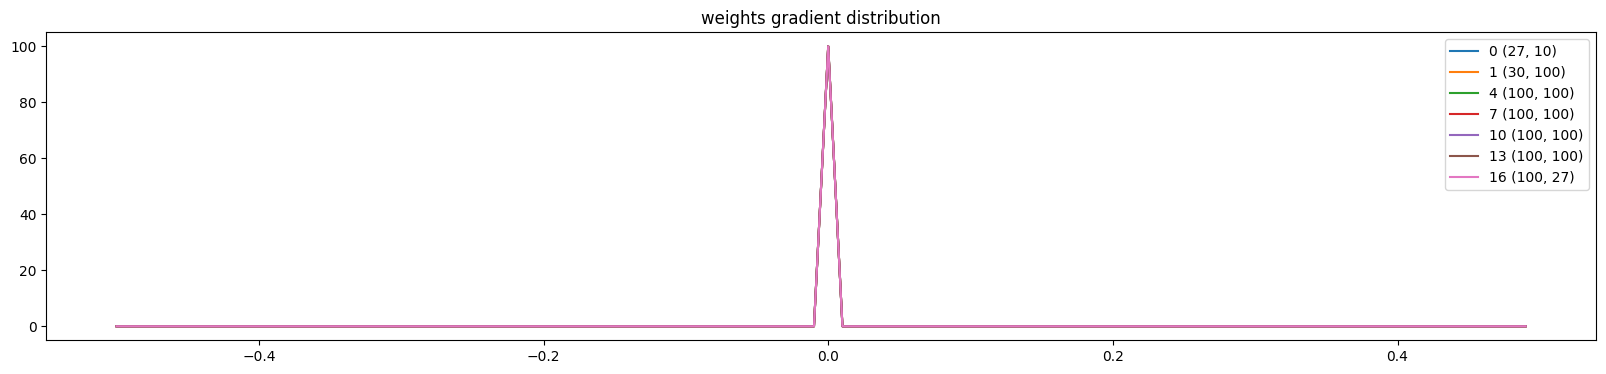

In [65]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

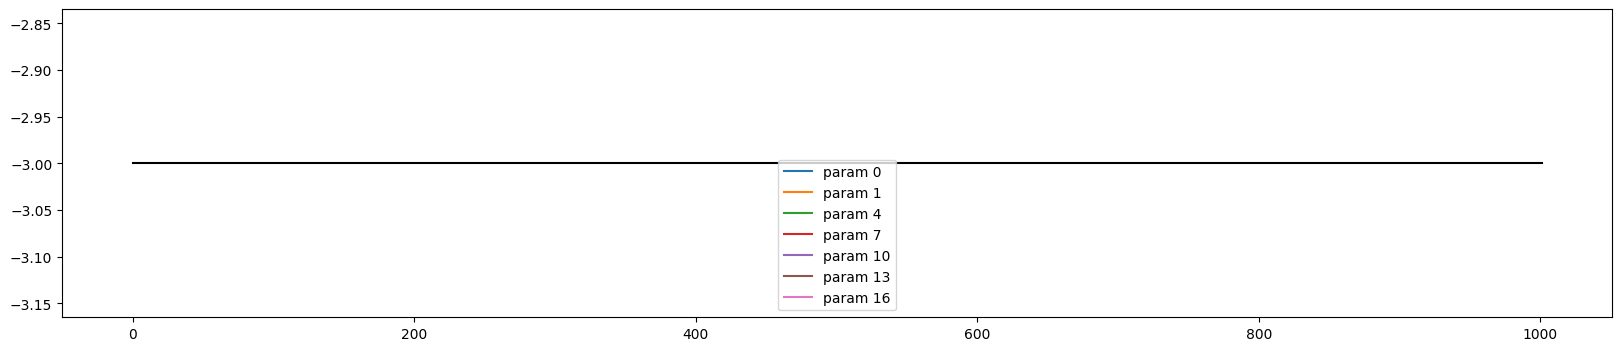

In [66]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [67]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (X_training, Y_training),
    'val': (X_validation, Y_validation),
    'test': (X_test, Y_test),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.8335647583007812
val 2.8324458599090576


In [68]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size_context # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

eriaaimyazhreelmnd.
ryal.
retmrsjejdrleg.
azeeedieliihemi.
realeieiseananarneatzimhlkaa.
n.
sadbvrgahimies.
.
n.
jr.
eelqlxntpuofnu.
amnedar.
yirue.
ehs.
laajaysknyaa.
hia.
nalyaisun.
zajelveuren.
.
.


### Excercise of the Video

E01: I did not get around to seeing what happens when you initialize all weights and biases to zero. Try this and train the neural net. You might think either that 1) the network trains just fine or 2) the network doesn't train at all, but actually it is 3) the network trains but only partially, and achieves a pretty bad final performance. Inspect the gradients and activations to figure out what is happening and why the network is only partially training, and what part is being trained exactly.

The thing that happens when you make the initialization to 0's in the Weights, its that is not trained at all, or only trained in the 14 layer 